In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from utils.model_saver import *
from utils.model_classes import SimpleTransformer

from utils.embedding_transformer_utils import (
    get_torch_device,
    load_pair_embedding_transformer_model,
    sample_dataframe,
    set_torch_seed,
)

PROJECT_ROOT = Path().resolve().parent.parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

GRAPH_FEATURES_PATH = PROJECT_ROOT / 'data' / 'graph_features'
TRAIN_PATH = GRAPH_FEATURES_PATH / 'final_train.parquet'
VAL_PATH = GRAPH_FEATURES_PATH / 'final_val.parquet'
TEST_PATH = GRAPH_FEATURES_PATH / 'final_test.parquet'

RANDOM_STATE = 42

import torch
# Detect device: 'cuda' if available, else 'cpu'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# for parallelization
N_JOBS = -1

Using device: cuda
Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Data: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/data/exploded_splits
Using device: cuda


# KNN based Model - on graph features
By leveraging graph features (network info), we treat the problem as a supervised learning task.

To ensure code quality and reusability, we implement a custom class hierarchy:

- `BaseModel`: An abstract class that defines the blueprint for all models. It enforces the implementation of `preprocess()` method and provides standardized `train_pipeline` and `test_pipeline` methods.

- `KNNModel`: The concrete implementation of the baseline. It encapsulates the feature engineering logic (dropping non-feature columns) and stateful preprocessing (storing a `StandardScaler` to ensure the test set is scaled using training statistics).


## 1. Import dataframe with graph features

In [2]:
# splitting
df_train = pd.read_parquet(TRAIN_PATH)
df_val = pd.read_parquet(VAL_PATH)
df_test = pd.read_parquet(TEST_PATH)

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})


Split sizes: {'train': 2162520, 'test': 396382, 'val': 391242}


In [3]:
set_torch_seed(RANDOM_STATE)

MAX_TRAIN_SAMPLES = len(df_train)
MAX_VAL_SAMPLES = len(df_val)
MAX_TEST_SAMPLES = len(df_test)

TRAINING_PARAMS = {
    "epochs": 15,
    "batch_size": 512,
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "patience": 2,
}

MODEL_PARAMS = {
    "embedding_dim": 64,
    "d_model": 64,
    "nhead": 8,
    "num_layers": 2,
    "dim_feedforward": 128,
    "dropout": 0.15,
}

# Campionamento solo per velocizzare gli esperimenti: non cambia il formato dati.
df_train_model = sample_dataframe(df_train, MAX_TRAIN_SAMPLES, RANDOM_STATE)
df_val_model = sample_dataframe(df_val, MAX_VAL_SAMPLES, RANDOM_STATE)
df_test_model = sample_dataframe(df_test, MAX_TEST_SAMPLES, RANDOM_STATE)

print("Model split sizes:", {"train": len(df_train_model), "val": len(df_val_model), "test": len(df_test_model)})

Model split sizes: {'train': 2162520, 'val': 391242, 'test': 396382}


## 2. Baseline Model

In [ ]:
Transformer_baseline = SimpleTransformer('Transformer_baseline',device=DEVICE, n_jobs=N_JOBS)
Transformer_baseline.train_pipeline(df_train, df_val, random_state=RANDOM_STATE)

[Transformer_baseline] Preprocessing 2162520 rows...


/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Label distribution:
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64
[Transformer_baseline] Starting training...


epoch 1 train:   0%|          | 0/4224 [00:00<?, ?it/s]

predict:   0%|          | 0/765 [00:00<?, ?it/s]

...

{'epoch': 2, 'train_loss': 0.2197699595940968, 'val_f1_weighted': 0.3915725060078598}


epoch 3 train:   0%|          | 0/4224 [00:00<?, ?it/s]

predict:   0%|          | 0/765 [00:00<?, ?it/s]

{'epoch': 3, 'train_loss': 0.19490788133085107, 'val_f1_weighted': 0.6602529117132205}


epoch 4 train:   0%|          | 0/4224 [00:00<?, ?it/s]

[Transformer_baseline] Preprocessing 396382 rows...
Label distribution:
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64


predict:   0%|          | 0/775 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0     0.6488    0.9734    0.7786    198191
           1     0.9468    0.4731    0.6309    198191

    accuracy                         0.7233    396382
   macro avg     0.7978    0.7233    0.7048    396382
weighted avg     0.7978    0.7233    0.7048    396382



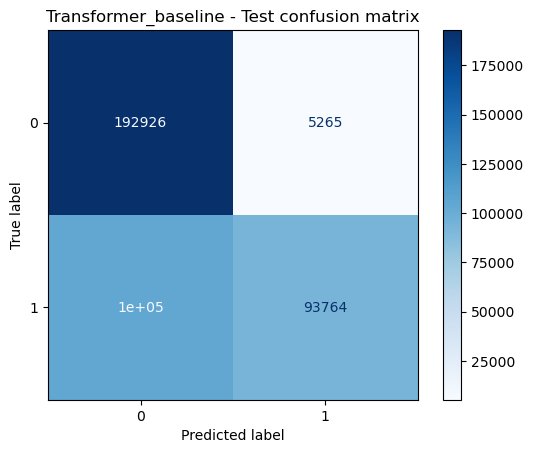

{'accuracy': 0.7232669495587589,
 'f1_weighted': 0.7047916566115983,
 'precision_weighted': 0.7978225506032129,
 'recall_weighted': 0.7232669495587589}

In [ ]:
Transformer_baseline.test_pipeline(df_test)

> todo comments

## 3. Hypertuning
Given the high dimensionality of embeddings and the large number of records, KNN can be computationally expensive. To optimize performance, we perform `GridSearchCV` on a representative subset of the data.

We utilize a `PredefinedSplit` strategy. Instead of standard K-fold cross-validation, we manually specify which samples belong to the training fold and which belong to the validation fold. This ensures that the model is tuned on the exact data distribution intended for validation without leakage from the training set.

In [ ]:
# Drastically reduce the dataset for tuning to avoid Out-Of-Memory (OOM) crashes
# KNN with 3M rows and 128-256 features is extremely RAM-intensive
max_tuning_samples = 50000 
param_grid = {
    'n_neighbors': [5, 9, 12, 15], # Reduced number of parameters
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [ ]:
# tuning
Transformer = SimpleTransformer("Transformer")
Transformer.hypertune_pipeline(df_train, df_val, param_grid, 
                               max_tuning_samples=max_tuning_samples,
                               scoring='f1_weighted',
                               n_jobs=N_JOBS)

TypeError: BaseModel.grid_search() got an unexpected keyword argument 'n_jobs'

## 4. Final model with best params
Once the optimal hyperparameters (number of neighbors, weight function, and distance metric) are found, the model is retrained on the full training set.

Performance is assessed using:
- Weighted F1-Score: To account for any slight imbalances in class distribution.
- Confusion Matrix: To visualize Type I and Type II errors.
- Classification Report: Providing precision, recall, and accuracy at a granular level.

[KNN_graph] Preprocessing 1000 rows...
Label distribution:
is_reference_valid
1    0.532
0    0.468
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.7559    0.8932    0.8188       468
           1     0.8881    0.7462    0.8110       532

    accuracy                         0.8150      1000
   macro avg     0.8220    0.8197    0.8149      1000
weighted avg     0.8262    0.8150    0.8147      1000



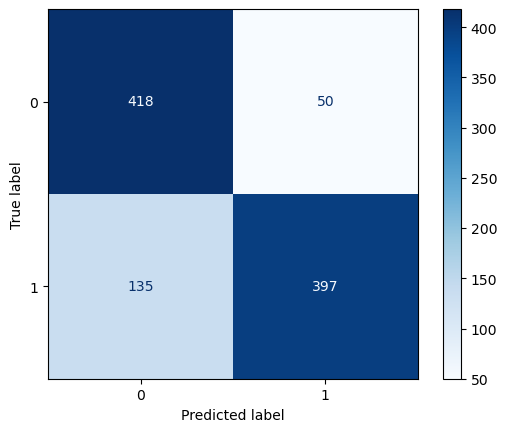

In [ ]:
KNN_graph.test_pipeline(df_test.sample(1000))

## 5. Save the Model pretrained
Finally, the trained model and its associated metadata (parameters, data source name, and performance summary) are saved using a custom `save_model_artifact` utility, allowing for easy deployment or further testing.

In [ ]:
from utils.model_saver import save_model_artifact
MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'

save_model_artifact(T, df_name='graph_features', 
                    model_name="Best_KNN_graph_based", 
                    relative_model_dir=MODEL_SAVE_PATH)